In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('heart.csv')

In [3]:
data=df

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
df.shape

(918, 12)

In [6]:
df.groupby('Sex')['HeartDisease'].sum()

Sex
F     50
M    458
Name: HeartDisease, dtype: int64

In [7]:
df[(df['HeartDisease']==1)&(df['Age']>30) & (df['Sex']=='M')][0:5]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
11,58,M,ATA,136,164,0,ST,99,Y,2.0,Flat,1
13,49,M,ASY,140,234,0,Normal,140,Y,1.0,Flat,1
16,38,M,ASY,110,196,0,Normal,166,N,0.0,Flat,1
18,60,M,ASY,100,248,0,Normal,125,N,1.0,Flat,1


In [8]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [9]:
x=df[df['RestingBP']<130]
y=df[df['RestingBP']>130]

In [10]:
# df['BP_Group']=df['RestingBP'].apply(lambda x:'Below 130' if x <130 else 'Above 130' )
# plt.figure(figsize=(6,4))
# sns.boxplot(x='BP_Group', y='RestingBP', data=df)
# plt.show()

In [11]:
df[(df['Cholesterol']>200) & (df['RestingBP']>=120) & (df['Age']<=40)][0:5]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
10,37,F,NAP,130,211,0,Normal,142,N,0.0,Up,0


In [12]:
df.shape

(918, 12)

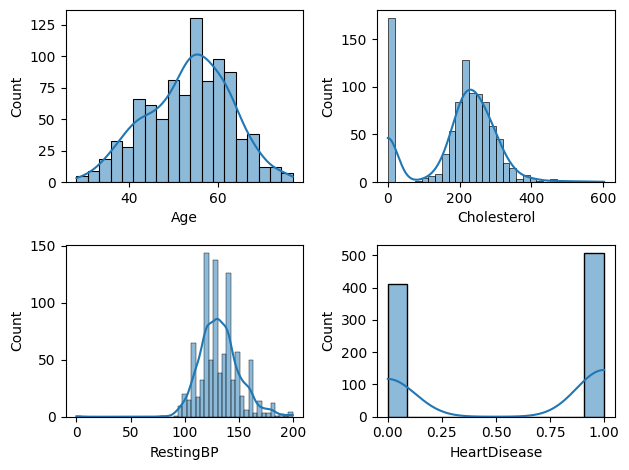

In [13]:
# Distribution of Table
def plots(var,x):
    plt.subplot(2,2,x)
    sns.histplot(df[var],kde=True)
plots('Age',1) 
plots('Cholesterol',2)
plots('RestingBP',3)
plots('HeartDisease',4)

plt.tight_layout()

In [14]:
df[(df['Cholesterol']>=10) &(df['Cholesterol']<=100) ]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
78,52,M,ATA,140,100,0,Normal,138,Y,0.0,Up,0
98,56,M,ASY,120,85,0,Normal,140,N,0.0,Up,0
444,56,M,ASY,120,100,0,Normal,120,Y,1.5,Flat,1


In [15]:
# Replaceing Zero VAlues with Mean of All Same Column Values and ROund offing them with 2
col=df.loc[df['Cholesterol'] !=0,'Cholesterol'].mean()
df['Cholesterol']=df['Cholesterol'].replace(0,col)
df['Cholesterol']=df['Cholesterol'].round(2)

In [16]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [17]:
df['Cholesterol'].min()

85.0

In [18]:
df[df['RestingBP']<50]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,244.64,0,Normal,155,N,1.5,Flat,1


In [19]:
rb=df.loc[df['RestingBP'] !=0,'RestingBP'].mean()

In [20]:
rb

132.54089422028352

In [21]:
# Replaceing Zero with Round off and Mean

In [22]:
df['RestingBP']=df['RestingBP'].replace(0,rb)
df['RestingBP']=df['RestingBP'].round(2)

In [23]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [24]:
df['RestingBP'].min()

80.0

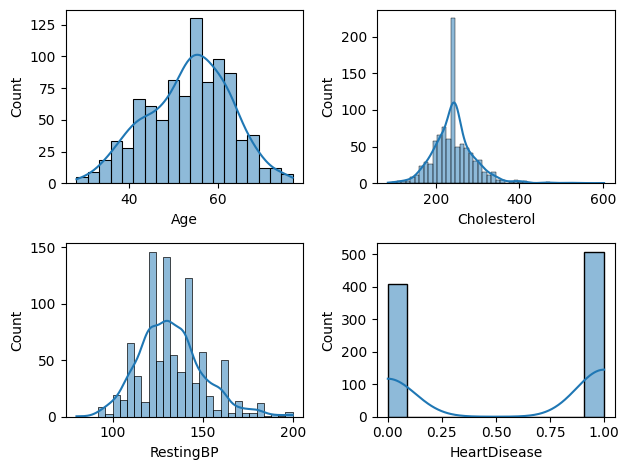

In [25]:
# Distribution of Table
def plots(var,x):
    plt.subplot(2,2,x)
    sns.histplot(df[var],kde=True)
plots('Age',1) 
plots('Cholesterol',2)
plots('RestingBP',3)
plots('HeartDisease',4)

plt.tight_layout()

In [26]:
df['Cholesterol'].value_counts()

Cholesterol
244.64    172
254.00     11
223.00     10
220.00     10
230.00      9
         ... 
392.00      1
316.00      1
153.00      1
466.00      1
131.00      1
Name: count, Length: 222, dtype: int64

In [27]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [28]:
plt.figure(figsize=(5,4))

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Axes: xlabel='ChestPainType', ylabel='count'>

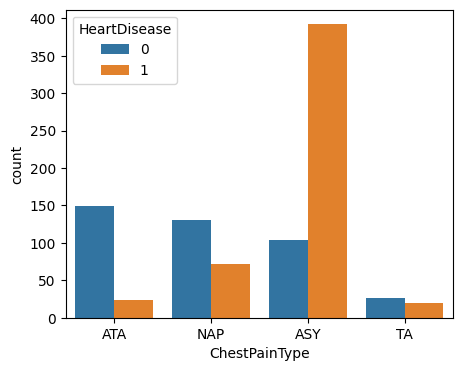

In [29]:
plt.figure(figsize=(5,4))

sns.countplot(x=df['ChestPainType'], hue=df['HeartDisease'])

In [30]:
df['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [31]:
df[df['ChestPainType']=='ATA'][['RestingBP','Cholesterol']].sort_values(by='RestingBP',ascending=False)

,RestingBP,Cholesterol
759,192.0,283.0
109,190.0,241.0
585,180.0,285.0
123,180.0,393.0
274,180.0,295.0
...,...,...
658,101.0,197.0
151,100.0,159.0
60,100.0,253.0
203,100.0,219.0


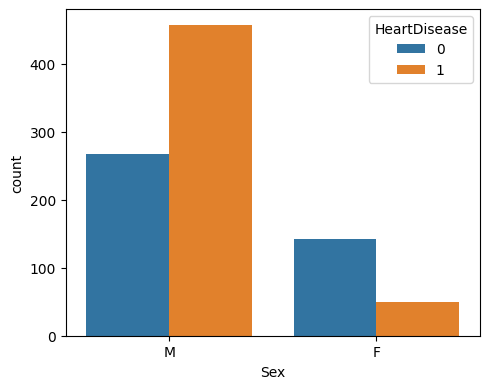

In [32]:
plt.figure(figsize=(5,4))
sns.countplot(x=df['Sex'],hue=df['HeartDisease'])
plt.tight_layout()

In [33]:
df['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

In [34]:
df['FastingBS'].value_counts()

FastingBS
0    704
1    214
Name: count, dtype: int64

<Axes: xlabel='FastingBS', ylabel='count'>

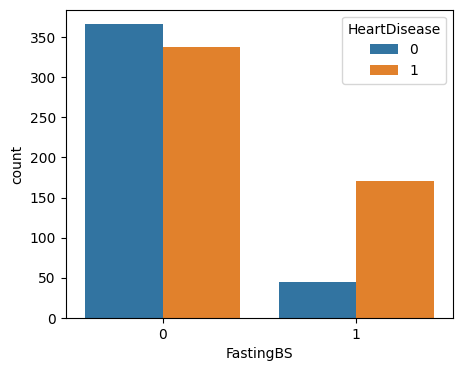

In [35]:
plt.figure(figsize=(5,4))
sns.countplot(x=df['FastingBS'],hue=df['HeartDisease'])

In [36]:
df.sort_values(by='Cholesterol' ,ascending=False)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
149,54,M,ASY,130.0,603.0,1,Normal,125,Y,1.0,Flat,1
616,67,F,NAP,115.0,564.0,0,LVH,160,N,1.6,Flat,0
76,32,M,ASY,118.0,529.0,0,Normal,130,N,0.0,Flat,1
30,53,M,NAP,145.0,518.0,0,Normal,130,N,0.0,Flat,1
250,44,M,ASY,135.0,491.0,0,Normal,135,N,0.0,Flat,1
...,...,...,...,...,...,...,...,...,...,...,...,...
541,76,M,NAP,104.0,113.0,0,LVH,120,N,3.5,Down,1
571,69,M,ASY,140.0,110.0,1,Normal,109,Y,1.5,Flat,1
444,56,M,ASY,120.0,100.0,0,Normal,120,Y,1.5,Flat,1
78,52,M,ATA,140.0,100.0,0,Normal,138,Y,0.0,Up,0


<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

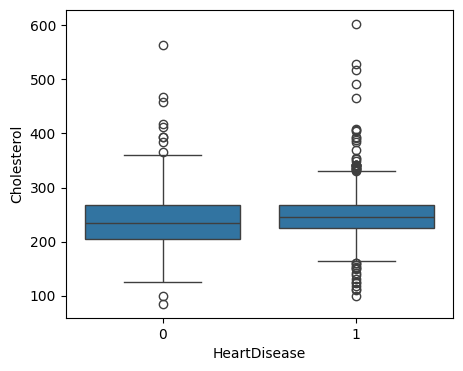

In [37]:
plt.figure(figsize=(5,4))
sns.boxplot(x='HeartDisease',y='Cholesterol',data=df)

<Axes: >

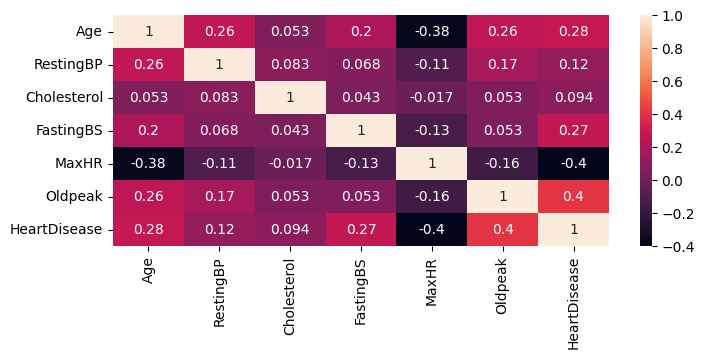

In [38]:
# Finding CoRelation Between Data
plt.figure(figsize=(8,3))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [39]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


<Axes: xlabel='Oldpeak', ylabel='Count'>

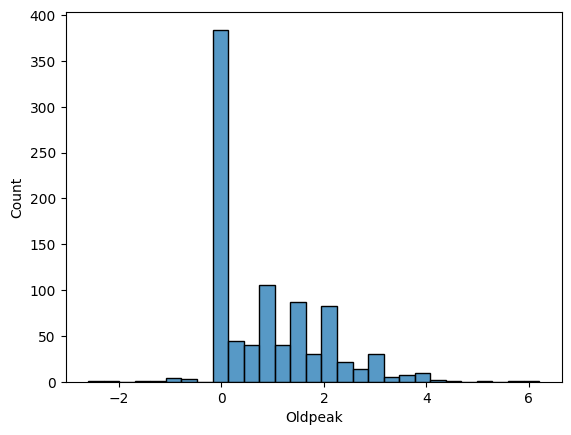

In [40]:
sns.histplot(df['Oldpeak'])

### Data Preprocessing 

In [41]:
df_encode=pd.get_dummies(df)

In [42]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [43]:
df_encode=df_encode.astype(int)

In [44]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
std=StandardScaler()

In [47]:
df_final=df_encode.copy()
col=['Age','RestingBP','Cholesterol','FastingBS','MaxHR']

In [48]:
df_final[col]=std.fit_transform(df_final[col])

In [49]:
df_final.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,-0.551341,1.382928,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,-0.551341,0.754157,1,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,-0.551341,-1.525138,0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,-0.584556,0.303651,-0.572651,-0.551341,-1.132156,1,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,0.051881,0.971054,-0.929194,-0.551341,-0.581981,0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [50]:
from sklearn.model_selection import train_test_split

In [51]:
x=df_final.drop(['HeartDisease'],axis=1)
y=df_final[['HeartDisease']]

In [52]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [53]:
### Now Train Data Into Calssification Model

In [54]:
from sklearn.linear_model import LogisticRegression
LRmodel=LogisticRegression()

In [55]:
LRmodel.fit(x_train,y_train)

C:\Users\IKRAM RIND\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [56]:
y_pred=LRmodel.predict(x_test)

In [57]:
y_pred

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1])

In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8695652173913043
[[68  9]
 [15 92]]


In [59]:
accuracy_score(y_test, y_pred)

0.8695652173913043

In [63]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85        77
           1       0.91      0.86      0.88       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184

